In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

In [55]:
%run pymongo-ingestion.ipynb

Successfully connected to MongoDB!
Document count: 768
10
10
[{'Age': 50.0,
  'BMI Category': 'obese',
  'Blood Pressure': 72.0,
  'Body Mass Index': 33.6,
  'Care Path': 'high-risk',
  'Clinic Region': 'North',
  'Diabetes Pedigree Function': 0.627,
  'Glucose': 148.0,
  'Insulin': 126.0,
  'Outcome': 1.0,
  'Patient Segment': 'adult',
  'Pregnancies': 6.0,
  'Skin Thickness': 35.0,
  '_id': ObjectId('6a246afccf1525005e38abee')},
 {'Age': 31.0,
  'BMI Category': 'overweight',
  'Blood Pressure': 66.0,
  'Body Mass Index': 26.6,
  'Care Path': 'routine follow-up',
  'Clinic Region': 'South',
  'Diabetes Pedigree Function': 0.351,
  'Glucose': 85.0,
  'Insulin': 126.0,
  'Outcome': 0.0,
  'Patient Segment': 'senior',
  'Pregnancies': 1.0,
  'Skin Thickness': 29.0,
  '_id': ObjectId('6a246afccf1525005e38abef')},
 {'Age': 32.0,
  'BMI Category': 'normal',
  'Blood Pressure': 64.0,
  'Body Mass Index': 23.3,
  'Care Path': 'urgent monitoring',
  'Clinic Region': 'North',
  'Diabetes Pedigr

In [56]:
MONGO_CONFIG = {
    "user": "labuser",
    "password": "labpass",
    "host": "localhost",
    "port": 27017,
    "database": "pima_indians_diabetes"
}

COLLECTION_NAME = 'diabetes'

In [57]:
db = MongoDatabase(MONGO_CONFIG)
db.connect()
executor = MongoExecutor(db, COLLECTION_NAME)

print(f'Connected to database! Total documents: {executor.count_documents({})}')

Connected to database! Total documents: 768


In [58]:
df = pd.DataFrame(executor.select({}, limit=None))
df = df.drop(columns=['_id'])
df.sample(5)

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,Body Mass Index,Diabetes Pedigree Function,Age,Outcome,BMI Category,Clinic Region,Care Path,Patient Segment
92,7.0,81.0,78.0,40.0,48.0,46.7,0.261,42.0,0.0,normal,North,routine follow-up,adult
353,1.0,270.0,62.0,12.0,215.0,68.0,0.580,24.0,0.0,overweight,South,routine follow-up,senior
521,3.0,124.0,80.0,33.0,130.0,33.2,0.305,26.0,0.0,obese,South,routine follow-up,senior
466,0.0,74.0,52.0,10.0,36.0,27.8,0.269,22.0,0.0,overweight,North,NaN,adult
280,0.0,119.0,70.0,NaN,126.0,37.9,0.334,30.0,1.0,obese,North,routine follow-up,adult


In [59]:
df.shape

(768, 13)

## EDA

### 1. Inspecting ingestion dataset

In [60]:
df.describe()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,Body Mass Index,Diabetes Pedigree Function,Age,Outcome
count,768.000000,768.000000,665.000000,541.000000,768.000000,768.000000,768.000000,768.000000,725.000000
mean,3.839844,130.615885,72.240602,29.153420,147.480469,33.393424,0.471876,49.611979,0.393103
std,3.375520,64.921110,12.301405,10.476982,122.577287,9.784432,0.331329,80.746310,0.488777
min,-2.000000,44.000000,24.000000,7.000000,14.000000,-5.000000,0.078000,21.000000,0.000000
25%,1.000000,102.000000,64.000000,22.000000,126.000000,29.300000,0.243750,25.000000,0.000000
50%,3.000000,119.000000,72.000000,29.000000,126.000000,32.400000,0.372500,30.000000,0.000000
75%,6.000000,140.000000,80.000000,36.000000,126.000000,35.125000,0.626250,41.000000,1.000000
max,17.000000,999.000000,122.000000,99.000000,1500.000000,109.000000,2.420000,720.000000,1.000000


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 768 non-null    float64
 1   Glucose                     768 non-null    float64
 2   Blood Pressure              665 non-null    float64
 3   Skin Thickness              541 non-null    float64
 4   Insulin                     768 non-null    float64
 5   Body Mass Index             768 non-null    float64
 6   Diabetes Pedigree Function  768 non-null    float64
 7   Age                         768 non-null    float64
 8   Outcome                     725 non-null    float64
 9   BMI Category                647 non-null    str    
 10  Clinic Region               721 non-null    str    
 11  Care Path                   718 non-null    str    
 12  Patient Segment             701 non-null    str    
dtypes: float64(9), str(4)
memory usage: 99.6 KB


In [62]:
df['Outcome'] = df['Outcome'].astype('object')

Separating columns into numerical and categorical lists for easier analysis

In [63]:
num_list = list(df.select_dtypes(include='number').columns)
num_list

['Pregnancies',
 'Glucose',
 'Blood Pressure',
 'Skin Thickness',
 'Insulin',
 'Body Mass Index',
 'Diabetes Pedigree Function',
 'Age']

In [64]:
cat_list = list(df.select_dtypes(include='object').columns)
cat_list

C:\Users\aikyu\AppData\Local\Temp\ipykernel_33224\487944753.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_list = list(df.select_dtypes(include='object').columns)


['Outcome', 'BMI Category', 'Clinic Region', 'Care Path', 'Patient Segment']

In [65]:
df.duplicated().sum()

np.int64(0)

### 2. Numerical Analysis

In [66]:
for c in num_list:
    print(c, df[c].unique(), end='\n\n')

Pregnancies [ 6.  1.  8.  0.  5.  3. 10.  2.  4.  7.  9. 11. 13. -2. 15. 17. 12. 14.]

Glucose [148.  85. 183.  89. 137. 119.  78. 115. 197. 125. 999. 168. 139. 189.
 166. 100. 118. 103. 126.  99. 196. 143. 147. 145. 117. 109. 158.  88.
  92. 122. 138. 102.  90. 111. 180. 133. 106. 171. 159.  71. 105. 528.
 150.  73. 187. 146.  84. 399.  44. 141. 114. 129.  62.  95. 131. 112.
 113.  74.  83. 101. 110. 136. 107.  80. 123.  81. 134. 142. 144. 279.
 163. 151.  96. 155.  76. 160. 124.  97. 162. 132. 120. 173. 170.  93.
 384. 108. 154.  57. 156. 153. 188. 152. 104.  87.  79.  75. 130. 194.
 181. 128. 135. 324. 184. 179. 140. 177. 513. 543.  91. 417. 165.  86.
 191. 161. 501.  77. 182. 456. 157. 178. 116.  61. 270.  98. 127.  82.
 193.  72. 172.  94. 175. 195.  68. 252. 186. 164. 567. 198. 121. 363.
 176.  67. 174. 309. 167. 169. 366. 375. 402.  65. 459. 190.]

Blood Pressure [ 72.  66.  64.  40.  74.  nan  70.  96.  80.  60.  84.  30.  88.  90.
  94.  92.  75.  76.  58.  78.  68.  56.  50. 

It is recommended to remove extreme outliers that dont make sense realistically

In [67]:
def verify_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    outliers = (df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))
    if outliers.sum() > 0:
        return True, outliers
    return False

In [68]:
for c in num_list:
    print(verify_outliers(df,c)[0])
# there are outliers in every numerical column

True
True
True
True
True
True
True
True


In [69]:
float(str(396.0)[:-3])

39.0

These outliers are still within a normal expected age range for a medical dataset

In [70]:
for idx, value in df[verify_outliers(df,'Age')[1]]['Age'].items():
    if len(str(int(value)))>2:
        df.loc[idx, 'Age'] = float(str(value)[:-3])
df[verify_outliers(df,'Age')[1]]['Age']

30     72.0
123    69.0
148    65.0
221    66.0
263    63.0
294    65.0
361    63.0
362    65.0
453    72.0
459    81.0
479    63.0
489    67.0
495    66.0
537    67.0
552    66.0
666    70.0
674    68.0
684    69.0
759    66.0
763    63.0
Name: Age, dtype: float64

The expected age range is 21~81, quickly fixing the badly replaced outlier:

In [71]:
df['Age'] = df['Age'].replace(15., 50.)

In [72]:
df['Age'].describe()

count    768.000000
mean      33.335938
std       11.454765
min       21.000000
25%       25.000000
50%       30.000000
75%       40.000000
max       81.000000
Name: Age, dtype: float64

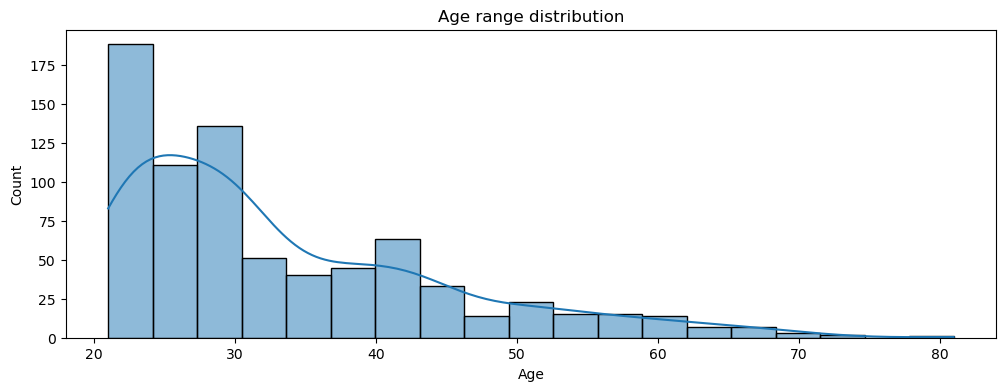

In [73]:
plt.figure(figsize=(12,4))
sns.histplot(df.Age, kde=True)
plt.title('Age range distribution')
plt.show()

For patients going through medical emergencies, a glucose level of 50 or lower or of 600 or higher is possible. However the 999 data point seems like a clerical error, it will be substituted with the median.

In [74]:
df[verify_outliers(df,'Glucose')[1]]['Glucose']

10     999.0
53     528.0
61     399.0
62      44.0
98     279.0
140    384.0
202    324.0
235    513.0
236    543.0
242    417.0
300    501.0
323    456.0
353    270.0
543    252.0
549    567.0
561    198.0
582    363.0
600    324.0
608    456.0
644    309.0
700    366.0
701    375.0
713    402.0
744    459.0
751    363.0
Name: Glucose, dtype: float64

In [75]:
df['Glucose'] = df['Glucose'].replace(999., df['Glucose'].drop(index=10).median())

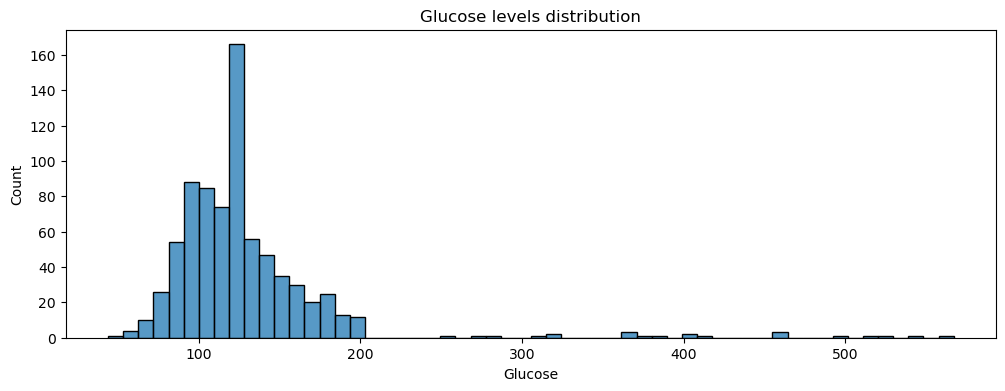

In [76]:
plt.figure(figsize=(12,4))
sns.histplot(df.Glucose)
plt.title('Glucose levels distribution')
plt.show()

Other outliers checked are within the range of what can be expected normally or during medical emergencies

Transform negative values to missing values

In [77]:
df[num_list] = df[num_list].mask(df[num_list]<0, np.nan)

In [78]:
for c in num_list:
    print(c, df[c].unique(), end='\n\n')

Pregnancies [ 6.  1.  8.  0.  5.  3. 10.  2.  4.  7.  9. 11. 13. nan 15. 17. 12. 14.]

Glucose [148.  85. 183.  89. 137. 119.  78. 115. 197. 125. 168. 139. 189. 166.
 100. 118. 103. 126.  99. 196. 143. 147. 145. 117. 109. 158.  88.  92.
 122. 138. 102.  90. 111. 180. 133. 106. 171. 159.  71. 105. 528. 150.
  73. 187. 146.  84. 399.  44. 141. 114. 129.  62.  95. 131. 112. 113.
  74.  83. 101. 110. 136. 107.  80. 123.  81. 134. 142. 144. 279. 163.
 151.  96. 155.  76. 160. 124.  97. 162. 132. 120. 173. 170.  93. 384.
 108. 154.  57. 156. 153. 188. 152. 104.  87.  79.  75. 130. 194. 181.
 128. 135. 324. 184. 179. 140. 177. 513. 543.  91. 417. 165.  86. 191.
 161. 501.  77. 182. 456. 157. 178. 116.  61. 270.  98. 127.  82. 193.
  72. 172.  94. 175. 195.  68. 252. 186. 164. 567. 198. 121. 363. 176.
  67. 174. 309. 167. 169. 366. 375. 402.  65. 459. 190.]

Blood Pressure [ 72.  66.  64.  40.  74.  nan  70.  96.  80.  60.  84.  30.  88.  90.
  94.  92.  75.  76.  58.  78.  68.  56.  50.  82. 

For every numerical column, substitute missing values by the column's median

In [79]:
for c in num_list:
    df[c] = df[c].fillna(df[c].median())

In [80]:
(df[num_list].isna().sum()/len(df)*100).sort_values(ascending=False)

Pregnancies                   0.0
Glucose                       0.0
Blood Pressure                0.0
Skin Thickness                0.0
Insulin                       0.0
Body Mass Index               0.0
Diabetes Pedigree Function    0.0
Age                           0.0
dtype: float64

### 3. Categorical Analysis

In [81]:
for c in cat_list:
    print(c, df[c].unique(), end='\n\n')

Outcome [1.0 0.0 nan]

BMI Category <ArrowStringArray>
['obese', 'overweight', 'normal', 'underweight', nan]
Length: 5, dtype: str

Clinic Region <ArrowStringArray>
['North', 'South', nan]
Length: 3, dtype: str

Care Path <ArrowStringArray>
['high-risk', 'routine follow-up', 'urgent monitoring', 'routine', nan]
Length: 5, dtype: str

Patient Segment <ArrowStringArray>
['adult', 'senior', 'mid-age', nan]
Length: 4, dtype: str



Replacing missing values for the mode

In [82]:
(df[cat_list].isna().sum()/len(df)*100).sort_values(ascending=False)

BMI Category       15.755208
Patient Segment     8.723958
Care Path           6.510417
Clinic Region       6.119792
Outcome             5.598958
dtype: float64

In [83]:
for c in cat_list:
    df[c] = df[c].fillna(df[c].mode()[0])

In [84]:
(df[cat_list].isna().sum()/len(df)*100).sort_values(ascending=False)

Outcome            0.0
BMI Category       0.0
Clinic Region      0.0
Care Path          0.0
Patient Segment    0.0
dtype: float64

In [85]:
for c in cat_list:
    print(c, df[c].unique(), end='\n\n')

Outcome [1.0 0.0]

BMI Category <ArrowStringArray>
['obese', 'overweight', 'normal', 'underweight']
Length: 4, dtype: str

Clinic Region <ArrowStringArray>
['North', 'South']
Length: 2, dtype: str

Care Path <ArrowStringArray>
['high-risk', 'routine follow-up', 'urgent monitoring', 'routine']
Length: 4, dtype: str

Patient Segment <ArrowStringArray>
['adult', 'senior', 'mid-age']
Length: 3, dtype: str



In [86]:
(df[num_list].isna().sum()/len(df)*100).sort_values(ascending=False)

Pregnancies                   0.0
Glucose                       0.0
Blood Pressure                0.0
Skin Thickness                0.0
Insulin                       0.0
Body Mass Index               0.0
Diabetes Pedigree Function    0.0
Age                           0.0
dtype: float64

Standardizing unique value names

In [87]:
df['Care Path'] = df['Care Path'].replace('routine', 'routine follow-up')

In [88]:
df[df['Patient Segment']=='mid-age']['Age'].unique()

array([32., 59., 51., 30., 25., 21., 22., 23., 26., 34., 47., 24., 37.,
       29., 58., 41., 33., 45., 28., 38., 72., 60., 27., 66., 46., 50.,
       43., 69., 56., 42.])

In [89]:
df[df['Patient Segment']=='senior']['Age'].unique()

array([31., 53., 54., 51., 30., 50., 41., 57., 28., 56., 24., 58., 49.,
       23., 22., 60., 21., 25., 61., 27., 62., 39., 55., 65., 45., 29.,
       26., 52., 32., 38., 66., 63., 43., 48., 33., 37., 42., 34., 59.,
       44., 67., 46., 36.])

In [90]:
df[df['Patient Segment']=='adult']['Age'].unique()

array([50., 21., 33., 30., 26., 34., 57., 32., 39., 27., 41., 29., 43.,
       22., 38., 72., 28., 45., 35., 48., 31., 42., 44., 36., 24., 37.,
       40., 23., 25., 46., 69., 47., 60., 55., 49., 65., 56., 62., 81.,
       53., 52., 54., 70., 68., 63.])

In [91]:
conditions =[(df['Age'] >= 21) & (df['Age']< 60), (df['Age'] >= 60)]
df['Patient Segment'] = np.select(conditions, ['Adult', 'Senior'], default='unknown')

In [92]:
for c in cat_list:
    print(c, df[c].unique(), end='\n\n')

Outcome [1.0 0.0]

BMI Category <ArrowStringArray>
['obese', 'overweight', 'normal', 'underweight']
Length: 4, dtype: str

Clinic Region <ArrowStringArray>
['North', 'South']
Length: 2, dtype: str

Care Path <ArrowStringArray>
['high-risk', 'routine follow-up', 'urgent monitoring']
Length: 3, dtype: str

Patient Segment <ArrowStringArray>
['Adult', 'Senior']
Length: 2, dtype: str



In [93]:
df.describe()

,Pregnancies,Glucose,Blood Pressure,Skin Thickness,Insulin,Body Mass Index,Diabetes Pedigree Function,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.846354,129.470052,72.208333,29.108073,147.480469,33.442122,0.471876,33.335938
std,3.369057,56.836981,11.445960,8.791221,122.577287,9.685669,0.331329,11.454765
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,102.000000,65.750000,25.000000,126.000000,29.450000,0.243750,25.000000
50%,3.000000,119.000000,72.000000,29.000000,126.000000,32.400000,0.372500,30.000000
75%,6.000000,140.000000,78.000000,32.000000,126.000000,35.125000,0.626250,40.000000
max,17.000000,567.000000,122.000000,99.000000,1500.000000,109.000000,2.420000,81.000000


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pregnancies                 768 non-null    float64
 1   Glucose                     768 non-null    float64
 2   Blood Pressure              768 non-null    float64
 3   Skin Thickness              768 non-null    float64
 4   Insulin                     768 non-null    float64
 5   Body Mass Index             768 non-null    float64
 6   Diabetes Pedigree Function  768 non-null    float64
 7   Age                         768 non-null    float64
 8   Outcome                     768 non-null    object 
 9   BMI Category                768 non-null    str    
 10  Clinic Region               768 non-null    str    
 11  Care Path                   768 non-null    str    
 12  Patient Segment             768 non-null    str    
dtypes: float64(8), object(1), str(4)
memory usage: